# Chapter 12: Classification, and the Result That Was Too Good

<a href="https://colab.research.google.com/github/choilab-jefferson/medimage/blob/main/Chapter12_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Chapter 13 predicts survival time. This chapter predicts a yes-or-no answer — a **classification** —
and compares eight models on the same data to see which wins.

It also contains a mistake. Not a hypothetical one: a real data leak that appeared while writing
this notebook, produced a perfect score, and is reproduced here exactly as it happened. Learning to
recognize that pattern is worth more than any of the models.

By the end you will be able to:

1. Turn clinical records into a binary label without accidentally encoding the answer.
2. Rank features by how well each separates two groups.
3. Benchmark several models under nested cross-validation.
4. **Recognize a result that is too good, find the leak that caused it, and prove it.**
5. Explain why picking the best of eight models is itself a way to fool yourself.

## Setup

In [1]:
# --- Setup: Google Colab (primary) and local checkout (testing) ---------------
REPO_URL = "https://github.com/choilab-jefferson/medimage.git"
REPO_DIR = "medimage"

import os
import pathlib
import subprocess
import sys

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ModuleNotFoundError:
    IN_COLAB = False

if IN_COLAB:
    # On Colab the repository is not present yet, so clone it and install the
    # few packages that are not part of the default runtime.
    if not pathlib.Path(REPO_DIR).is_dir():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL], check=True)
    os.chdir(REPO_DIR)
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "pydicom", "remotezip"],
        check=True,
    )
else:
    # Locally the notebook already lives inside the repository; walk up until
    # we find the module that the notebooks import.
    root = pathlib.Path.cwd().resolve()
    while not (root / "medimage_data.py").is_file() and root != root.parent:
        root = root.parent
    os.chdir(root)

print("Running on Colab:", IN_COLAB)
print("Working directory:", pathlib.Path.cwd().name)

Running on Colab: False
Working directory: medimage


In [2]:
import subprocess
import sys

# pyradiomics is the default extraction engine, and an optional extra of
# qradiomics: PyPI ships no wheel for Python 3.10+, so it comes from git.
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "pyradiomics @ git+https://github.com/AIM-Harvard/pyradiomics.git",
                "qradiomics", "statsmodels", "lightgbm", "xgboost"], check=True)
print("installed")

installed


In [3]:
import json
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import medimage_data as md

paths = md.fetch_lung1_cohort(60)
WORK = paths["work"]

features = pd.read_csv(paths["analysis_ready"])
clinical = pd.read_csv(paths["clinical"])
print()
print(f"{len(features)} patients, {features.shape[1] - 3} radiomic features")

  LUNG1-035: no GTV-1 contour in the structure set, skipping


Lung1 cohort ready: 59 patients, 1130 features in work/lung1
Source: Aerts HJWL, Wee L, Rios Velazquez E, et al. (2019). Data From NSCLC-Radiomics. The Cancer Imaging Archive. https://doi.org/10.7937/K9/TCIA.2015.PF0M9REI  (CC BY-NC 3.0)

59 patients, 1130 radiomic features


## 1. Two labels

**Histology: squamous or not.** A genuine radiomics question — can texture see the tumor subtype
that a pathologist reports?

**Survival to two years.** Derived from the follow-up record: a patient is labeled 1 if they died
within 24 months.

The second label needs care. "Not dead within 24 months" is not the same as "alive at 24 months" —
a patient last seen at 8 months is neither. In this cohort nobody is censored before 24 months, so
the label is clean. That is worth checking rather than assuming, because the alternative silently
mislabels the very patients the model most needs to get right.

In [4]:
labels = clinical[["PatientID", "Histology"]].rename(columns={"PatientID": "patient_id"})
data = features.merge(labels, on="patient_id")

data["squamous"] = data.Histology.str.contains("squamous", case=False, na=False).astype(int)
data["dead_2y"] = ((data.OS_months < 24) & (data.OS_event == 1)).astype(int)
data = data.drop(columns=["Histology"])

censored_early = ((data.OS_months < 24) & (data.OS_event == 0)).sum()
print(f"squamous          {data.squamous.sum():3d} / {len(data)}")
print(f"died within 2 yrs {data.dead_2y.sum():3d} / {len(data)}")
print(f"censored before 24 months (would be unusable): {censored_early}")

squamous           23 / 59
died within 2 yrs  43 / 59
censored before 24 months (would be unusable): 0


## 2. Which single features separate the groups?

`qr analyze classify` fits a logistic regression per feature and reports the area under the ROC
curve — the probability that a randomly chosen positive case scores higher than a randomly chosen
negative one. 0.5 is a coin toss.

In [5]:
data.to_csv(WORK / "classify_squamous.csv", index=False)

subprocess.run(["qr", "analyze", "classify", "-i", str(WORK / "classify_squamous.csv"),
                "--outcome", "squamous", "-o", str(WORK / "univariate.csv")],
               check=True, capture_output=True)

univariate = pd.read_csv(WORK / "univariate.csv")
print(f"{len(univariate)} features tested, {(univariate.p < 0.05).sum()} with p < 0.05")
print(f"expected by chance alone: about {0.05 * len(univariate):.0f}")
print()
print(univariate.nsmallest(6, "p").to_string(index=False))

1132 features tested, 8 with p < 0.05
expected by chance alone: about 57

                                              feature      coef      auc        p
wavelet-LHL_gldm_SmallDependenceHighGrayLevelEmphasis  0.010482 0.714976 0.021062
                      wavelet-LHL_firstorder_Skewness -1.889446 0.682367 0.028310
                      wavelet-HLL_firstorder_Skewness -1.434120 0.704106 0.029923
                       wavelet-LHL_firstorder_Minimum -0.002538 0.706522 0.032429
                        wavelet-LHL_glcm_JointAverage  0.062402 0.704106 0.033140
                          wavelet-LHL_glcm_SumAverage  0.031201 0.704106 0.033140


The same arithmetic applies here as in Chapter 13. Testing about eleven hundred features at p < 0.05
yields roughly fifty-five "significant" ones from pure noise. A single small p-value drawn from a
list that long is not evidence of anything.

Which is why the real question is not "does any feature look associated" but "does a model built
from them predict patients it has never seen".

## 3. Benchmarking eight models

`qr ml benchmark` runs nested cross-validation: an outer loop holds out patients for testing, and
an inner loop tunes hyperparameters using only the training portion. That separation is what keeps
the tuning from quietly leaking test information into the model.

In [6]:
def benchmark(input_csv, outcome, outdir):
    subprocess.run(["qr", "ml", "benchmark", "-i", str(input_csv), "-o", outcome,
                    "--output-dir", str(outdir), "--cv", "5", "--inner-cv", "3"],
                   check=True, capture_output=True)
    return pd.read_csv(pathlib.Path(outdir) / "benchmark_cv_results.csv")


squamous_results = benchmark(WORK / "classify_squamous.csv", "squamous", WORK / "bench_squamous")
print(squamous_results[["model", "oof_auc", "cv_auc_mean", "cv_auc_std"]].to_string(index=False))

     model  oof_auc  cv_auc_mean  cv_auc_std
       SVM   0.5205       0.5237      0.0908
      LGBM   0.5145       0.5321      0.0819
       XGB   0.4771       0.4677      0.0877
        RF   0.4698       0.4702      0.0931
       GBM   0.4650       0.4557      0.1116
       MLP   0.4143       0.4070      0.1105
ExtraTrees   0.4136       0.4166      0.0680
        LR   0.3907       0.3814      0.1014


Every model lands between about 0.39 and 0.52 — chance, with noise. Radiomics does not predict
squamous histology in fifty-nine patients.

Note what the tool nonetheless reports: a **best** model. With eight candidates scored on the same
data, one of them wins by luck alone, and its score is biased upward precisely because it was chosen
for being highest. "We evaluated eight models and selected the best" is a multiple-comparisons
problem wearing a methods-section disguise. What this table shows is that the *spread*
contains 0.5.

## 4. Now the other label

Same features, same procedure, different outcome.

In [7]:
mortality_results = benchmark(WORK / "classify_squamous.csv", "dead_2y", WORK / "bench_leaky")
print(mortality_results[["model", "oof_auc", "oof_ap", "cv_auc_mean", "cv_auc_std"]]
      .to_string(index=False))

     model  oof_auc  oof_ap  cv_auc_mean  cv_auc_std
        LR   1.0000  1.0000       1.0000      0.0000
       GBM   1.0000  1.0000       1.0000      0.0000
      LGBM   1.0000  1.0000       1.0000      0.0000
       XGB   0.9985  0.9995       1.0000      0.0000
        RF   0.9971  0.9990       1.0000      0.0000
ExtraTrees   0.9426  0.9820       0.9322      0.0782
       MLP   0.6206  0.8147       0.6000      0.2008
       SVM   0.3990  0.7072       0.4034      0.1285


### Stop.

Four models at **AUC 1.000**, with a standard deviation of zero across folds. Perfect prediction of
who dies within two years, from CT texture.

That is not a discovery. Cancer outcomes are not perfectly predictable from anything, least of all
from fifty-nine patients. A result like this has one realistic explanation: **the answer is
somewhere in the input.**

This is the single most useful reflex in this chapter. An implausibly good score is a bug report.
Chase it before you celebrate it.

## 5. Finding the leak

Where could the answer be hiding? The label was built like this:

```python
data["dead_2y"] = ((data.OS_months < 24) & (data.OS_event == 1)).astype(int)
```

and `OS_months` and `OS_event` are **still columns in the table** handed to the model. The label is
a deterministic function of two of its own inputs. Any model that finds them can reconstruct the
answer exactly — and a decision tree finds them immediately.

The proof takes one line.

In [8]:
reconstructed = ((data.OS_months < 24) & (data.OS_event == 1)).astype(int)
print("label reconstructable from OS_months and OS_event alone:",
      bool((reconstructed == data.dead_2y).all()))
print()
print("columns the model was given that derive from the outcome:")
for column in ["OS_months", "OS_event"]:
    print(f"  {column}")

label reconstructable from OS_months and OS_event alone: True

columns the model was given that derive from the outcome:
  OS_months
  OS_event


In [9]:
clean = data.drop(columns=["OS_months", "OS_event", "squamous"])
clean.to_csv(WORK / "classify_clean.csv", index=False)

clean_results = benchmark(WORK / "classify_clean.csv", "dead_2y", WORK / "bench_clean")
print(clean_results[["model", "oof_auc", "oof_ap", "cv_auc_mean", "cv_auc_std"]]
      .to_string(index=False))

     model  oof_auc  oof_ap  cv_auc_mean  cv_auc_std
ExtraTrees   0.6453  0.7968       0.6317      0.1356
        RF   0.6047  0.7565       0.6192      0.1451
       GBM   0.6003  0.7752       0.5516      0.2116
       MLP   0.5465  0.7413       0.5956      0.0687
       XGB   0.5465  0.7824       0.5292      0.0694
      LGBM   0.5000  0.7275       0.5032      0.1527
        LR   0.4520  0.7018       0.4625      0.1619
       SVM   0.4353  0.7145       0.4244      0.1726


     model  with_leak  leak_removed
        LR     1.0000        0.4520
       GBM     1.0000        0.6003
      LGBM     1.0000        0.5000
       XGB     0.9985        0.5465
        RF     0.9971        0.6047
ExtraTrees     0.9426        0.6453
       MLP     0.6206        0.5465
       SVM     0.3990        0.4353


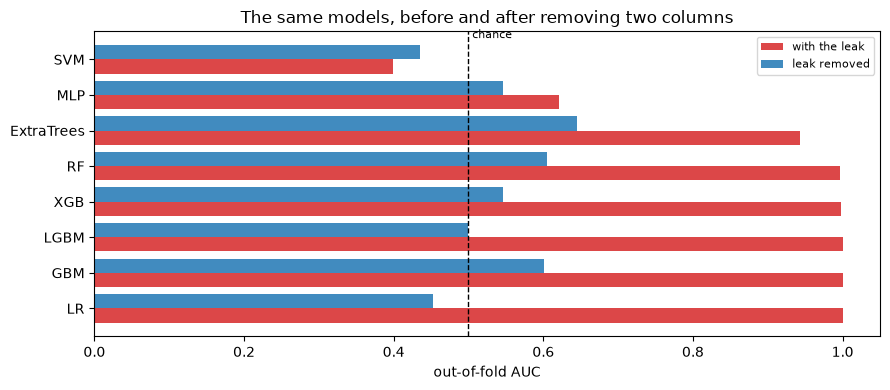

In [10]:
comparison = (mortality_results[["model", "oof_auc"]]
              .rename(columns={"oof_auc": "with_leak"})
              .merge(clean_results[["model", "oof_auc"]]
                     .rename(columns={"oof_auc": "leak_removed"}), on="model")
              .sort_values("with_leak", ascending=False))

print(comparison.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
y = np.arange(len(comparison))
ax.barh(y - 0.2, comparison.with_leak, height=0.4, color="tab:red", alpha=0.85,
        label="with the leak")
ax.barh(y + 0.2, comparison.leak_removed, height=0.4, color="tab:blue", alpha=0.85,
        label="leak removed")
ax.axvline(0.5, color="black", linestyle="--", linewidth=1)
ax.text(0.505, len(comparison) - 0.4, "chance", fontsize=8)
ax.set_yticks(y, comparison.model)
ax.set_xlabel("out-of-fold AUC")
ax.set_title("The same models, before and after removing two columns")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

Removing two columns takes the best model from a perfect 1.000 to about 0.65. Nothing else changed —
same features, same models, same cross-validation.

### Why this kind of leak is so easy to miss

The mistake was not exotic. It came from a completely ordinary sequence: merge the clinical table in,
derive a label from it, forget that the source columns are still sitting there. Notice that the
squamous run in section 3 had the same structure and did **not** blow up, because `Histology` was
dropped when the label was made. One line of difference.

Leaks that are worth watching for in imaging studies:

- **Outcome-derived columns**, as here.
- **Patient identifiers**, if they encode anything — a site prefix, a chronological ID.
- **Acquisition metadata** that correlates with the outcome: if the sick patients were scanned on the
  newer scanner, slice thickness predicts survival and the model learns the hospital's workflow.
- **Repeated patients** split across train and test — the model recognizes the person, not the disease.
- **Preprocessing fitted on all the data**, such as normalizing with a mean computed before the split.

The general defense is to ask one question of every column: *could this have been known only after
the outcome was?* If yes, it does not belong in the input.

## 6. The result after the fix

After the fix, the best model reaches roughly 0.65 out-of-fold on two-year mortality, and the spread
across models is wide. That is a weak signal in a small cohort — plausible, unremarkable, and worth
reporting exactly as it is.

It is also, unavoidably, a much less exciting sentence than the one available ten minutes earlier.
That asymmetry is the reason leaks survive to publication: the result that is wrong is the one that
looks like a finding.

## 7. Why not just hold out a test set?

Cross-validation reuses every patient: each is a test case in exactly one fold and a training case in
the others. The alternative most people reach for first is simpler — set some patients aside, never
look at them, and report what the model scores on them at the end. It is what a large study does and
what a regulator expects to see.

Here it does not work. It is worth watching that happen rather than being told.

`qr ml train` fits a model with its own internal cross-validation and writes it to disk. `qr ml
evaluate` loads that saved model, applies it to patients it has never seen, and reports hold-out
metrics. Below, the same 59 patients are split six times; the only thing that differs between the
splits is the random seed.

In [11]:
from sklearn.model_selection import train_test_split

clean_table = pd.read_csv(WORK / "classify_clean.csv")
holdout_dir = WORK / "holdout"
holdout_dir.mkdir(exist_ok=True)

rows = []
for seed in range(6):
    train, test = train_test_split(clean_table, test_size=0.3, random_state=seed,
                                   stratify=clean_table.dead_2y)
    train_csv, test_csv = holdout_dir / f"train{seed}.csv", holdout_dir / f"test{seed}.csv"
    train.to_csv(train_csv, index=False)
    test.to_csv(test_csv, index=False)

    model = holdout_dir / f"model{seed}.pkl"
    cv_metrics = holdout_dir / f"cv{seed}.json"
    report = holdout_dir / f"holdout{seed}.json"

    # There is no seed to pin here: qr ml train exposes none, and it does not need one.
    # The estimator is deterministic given its input, so the train/test split below is
    # the only thing that varies between these six runs -- which is the point.
    subprocess.run(["qr", "ml", "train", "-i", str(train_csv), "--task", "classify",
                    "--outcome", "dead_2y", "--model", str(model),
                    "--metrics", str(cv_metrics), "--top-features", "20"],
                   check=True, capture_output=True, text=True)
    subprocess.run(["qr", "ml", "evaluate", "-i", str(test_csv), "--model", str(model),
                    "--task", "classify", "--outcome", "dead_2y", "--report", str(report)],
                   check=True, capture_output=True, text=True)

    rows.append({"seed": seed,
                 "cv_auc": json.loads(cv_metrics.read_text())["cv_auc_mean"],
                 "holdout_auc": json.loads(report.read_text())["auc"]})

splits = pd.DataFrame(rows)
print(f"{len(train)} training / {len(test)} hold-out patients in every split")
print(f"{int(clean_table.dead_2y.sum())} of {len(clean_table)} patients dead at two years")
print()
print(splits.round(3).to_string(index=False))

41 training / 18 hold-out patients in every split
43 of 59 patients dead at two years

 seed  cv_auc  holdout_auc
    0   0.500        0.738
    1   0.694        0.477
    2   0.706        0.477
    3   0.572        0.523
    4   0.461        0.615
    5   0.517        0.738


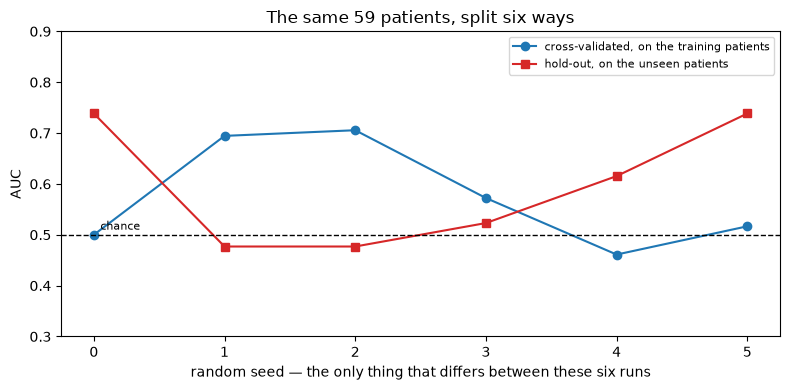

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(splits.seed, splits.cv_auc, "o-", color="tab:blue",
        label="cross-validated, on the training patients")
ax.plot(splits.seed, splits.holdout_auc, "s-", color="tab:red",
        label="hold-out, on the unseen patients")
ax.axhline(0.5, color="black", linestyle="--", linewidth=1)
ax.text(0.05, 0.51, "chance", fontsize=8)
ax.set_xlabel("random seed — the only thing that differs between these six runs")
ax.set_ylabel("AUC")
ax.set_ylim(0.3, 0.9)
ax.set_title("The same 59 patients, split six ways")
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

The hold-out AUC swings from roughly chance to roughly 0.74 across the six runs. Same patients, same
features, same pipeline — only the assignment of patients to the two sides changed.

Eighteen patients is the whole problem. With 43 of 59 dead at two years, a hold-out set of that size
holds about thirteen events and five survivors, and one patient crossing the decision boundary moves
the AUC by several points. Whichever seed you happened to run is the number you would report.

Notice too that the two curves do not track each other. The run with the worst cross-validated score
has one of the best hold-out scores; another has nearly the reverse. Neither estimate is stable
enough to corroborate the other, so seeing them agree would not have meant much either.

None of this is an argument against holding out a test set. It is an argument about **n**. At five
hundred patients, a held-out hundred and fifty gives an interval narrow enough to quote, and it
protects against exactly the kind of mistake section 5 uncovered. At fifty-nine, cross-validation
over everyone is the most the data will support, and section 3 already showed how wide even that is.

So what to report for this cohort is the cross-validated number, its spread, and a sentence saying
the cohort is too small to hold anything out. The third command in this family, `qr ml predict`,
applies a saved model to a feature table that has no labels at all — which is what you would reach
for once a model is finished and real patients start arriving.

## Exercises

1. Add `Overall.Stage` as a feature and re-run the mortality benchmark. The AUC will rise. Is that a
   leak, or is stage legitimately known before the outcome? Argue both sides.
2. Construct a leak on purpose: add a column equal to `dead_2y` plus a little noise, and find how
   much noise is needed before the AUC stops being suspicious.
3. Run the squamous benchmark with three different `--seed` values. How much does the winning model
   change? What does that say about reporting the best of eight?
4. Raise `--top-features` from 20 to 100 in the hold-out loop. Does the spread across seeds narrow
   or widen? Why would giving the model more features to choose from make a small test set less
   stable rather than more?

## References

- Kaufman S, Rosset S, Perlich C, Stitelman O. *Leakage in data mining: formulation, detection, and
  avoidance.* ACM Transactions on Knowledge Discovery from Data. 2012;6(4):1–21.
- Varoquaux G, Cheplygina V. *Machine learning for medical imaging: methodological failures and
  recommendations for the future.* npj Digital Medicine. 2022;5:48.
- Cawley GC, Talbot NLC. *On over-fitting in model selection and subsequent selection bias in
  performance evaluation.* Journal of Machine Learning Research. 2010;11:2079–2107.
- Aerts HJWL, et al. (2019). *Data From NSCLC-Radiomics.* The Cancer Imaging Archive.
  [doi:10.7937/K9/TCIA.2015.PF0M9REI](https://doi.org/10.7937/K9/TCIA.2015.PF0M9REI)